In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
import matplotlib.pyplot as plt
import os
from glob import glob

import requests
from bs4 import BeautifulSoup
import re

import warnings
warnings.filterwarnings('ignore')

## Setup paths

In [2]:
# Dakar paths
city_dir = 'mnt/2025-10-senegal-dakar'
user_dir = os.path.join(city_dir, '01-user-input')
spatial_dir = os.path.join(city_dir, '02-process-output', 'spatial')
temporal_dir = os.path.join(city_dir, '02-process-output', 'temporal')
tabular_dir = os.path.join(city_dir, '02-process-output', 'tabular')

print(f"City: {city_dir}")

City: mnt/2025-10-senegal-dakar


## Load AOI

In [3]:
# Load AOI
aoi_files = glob(os.path.join(user_dir, 'AOI', '*.shp'))
aoi = gpd.read_file(aoi_files[0]).to_crs('EPSG:4326')


#### CityPopulation.de

In [4]:
url = "https://www.citypopulation.de/en/senegal/cities/"

response = requests.get(url, timeout=30)
response.raise_for_status()
soup = BeautifulSoup(response.content, 'html.parser')
table = soup.find('section', {'id':'citysection'}).find('table')

citypop = pd.read_html(str(table))[0]

citypop = citypop[[col for col in citypop.columns if 'Population Census' in col]][citypop['Name']
                .str.contains('dakar', case=False, na=False)].T
citypop.columns = ['CityPopulation']
citypop['year'] = citypop.index.str.replace(r'[A-Za-z()\s]', '', regex=True) 
citypop['year'] = pd.to_datetime(citypop['year']).dt.year
citypop['CityPopulation'] = citypop['CityPopulation'].astype(int)
citypop = citypop[['CityPopulation', 'year']].reset_index(drop=True)
citypop


,CityPopulation,year
0,813317,1976
1,1375067,1988
2,1983093,2002
3,2646503,2013
4,3186088,2023


#### Oxford

In [13]:
# Check for Oxford/WorldPop data in tabular directory
oxford_files = glob(os.path.join('../03-multi-scan-materials', 'Oxford*.csv')) 
# oxford_full = pd.read_csv(oxford_files[0])



# .query("Location == 'Dakar' & Indicator == 'Total population'")

oxford_files

['../03-multi-scan-materials/Oxford Global Cities Data.csv']

In [ ]:
oxford_full = pd.read_csv(oxford_files[0]) .query("Location == 'Dakar' & Indicator == 'Total population'")

oxford_loc = pd.read_csv(os.path.join('../03-multi-scan-materials', 'oxford-locations.csv'))


In [24]:
len(np.unique(oxford_full[['Location']]))

1063

In [34]:
oxford_loc[oxford_loc['Location'].isin(oxford_full['Location'])]



,Location,Country
0,Algeria,Algeria
1,Algiers,Algeria
2,Constantine,Algeria
3,Oran,Algeria
4,Angola,Angola
...,...,...
1005,Suva,Fiji
1006,Auckland,New Zealand
1007,Christchurch,New Zealand
1008,Wellington,New Zealand


In [35]:
oxford_loc[~oxford_loc['Location'].isin(oxford_full['Location'])]

,Location,Country
17,Yaound�,Cameroon
26,C�te d'Ivoire,C�te d'Ivoire
126,Lom�,Togo
138,C�rdoba,Argentina
143,San Miguel De Tucum�n,Argentina
155,Bel�m,Brazil
157,Bras�lia,Brazil
159,Cuiab�,Brazil
161,Florian�polis,Brazil
175,Sao Jos� dos Campos,Brazil


In [77]:
oxford[['Units', 'Scale', 'Measurement']]

,Units,Scale,Measurement
55911,Persons,Thousands,Level


In [ ]:
pd.read_csv(oxford_files[0]).query("Location == 'Dakar' & Indicator == 'Total population'")

,Location,Country,Indicator,Product / Service,Income Band,Market Sector,Units,Scale,Measurement,2000,...,Seasonally adjusted,Base year price,Base year index,Historical end year,Historical end quarter,Date of last update,Source details,Additional source details,Location code,Indicator code
55911,Dakar,Senegal,Total population,NaN,NaN,NaN,Persons,Thousands,Level,1966.094,...,False,NaN,NaN,2013.0,NaN,16 November 2021,Geographic level: Estimated Functional Urban A...,NaN,SEN00153,POPTOTT


In [118]:
oxfordpop = oxford[[col for col in oxford.columns if col.isdigit()]].T
oxfordpop.columns = ['Oxford']
oxfordpop['year'] = oxfordpop.index.astype(int)
oxfordpop['Oxford'] = oxfordpop['Oxford']*1000
oxfordpop = oxfordpop[['Oxford', 'year']].reset_index(drop=True)
oxfordpop = oxfordpop[oxfordpop['year'] <= 2025]

## 3. GHS Population TIF

In [119]:
# Find GHS population rasters
pop_tifs = glob(os.path.join(spatial_dir, '*ghs_pop*.tif')) 
world_pop = glob(os.path.join(spatial_dir, '*population*.tif'))

pop_tifs

['mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E1975.tif',
 'mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E2000.tif',
 'mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E2015.tif',
 'mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E2005.tif',
 'mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E2010.tif',
 'mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E2020.tif',
 'mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E2030.tif',
 'mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E2025.tif',
 'mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E1985.tif',
 'mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E1990.tif',
 'mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E1980.tif',
 'mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_ghs_pop_E1995.tif']

In [145]:
from rasterstats import zonal_stats

years = [1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
pops = []
for year, tifs in zip(years, sorted(pop_tifs)):
    r = rxr.open_rasterio(tifs, masked=True)
    pop_clipped = r.rio.clip(aoi.geometry.values, aoi.crs, drop=True)
    stats = pop_clipped.sum().values.item()
    pops.append(stats)

    
ghspop = pd.DataFrame({'GHS': pops, 'year': years})
ghspop['GHS'] = ghspop['GHS'].astype(int)

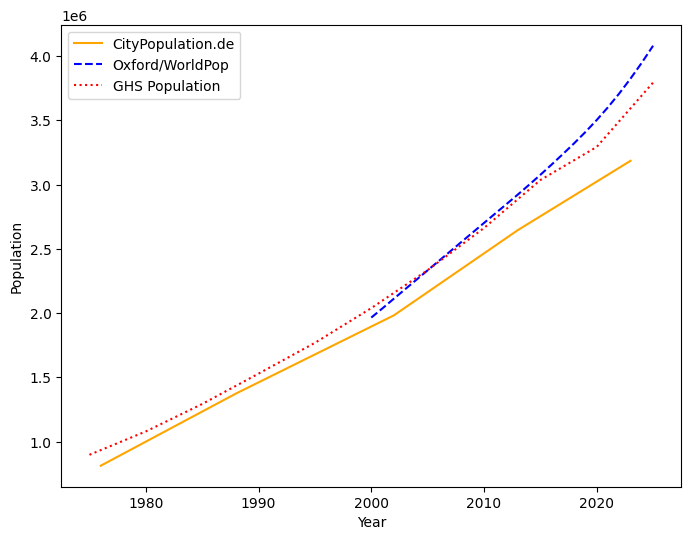

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(citypop['year'], citypop['CityPopulation'], label='CityPopulation.de', linestyle='-', color='orange')
plt.plot(oxfordpop['year'], oxfordpop['Oxford'], label='Oxford/WorldPop', linestyle='--', color ='blue')
plt.zplot(ghspop['year'], ghspop['GHS'],  label='GHS Population', linestyle=':', color='red')
plt.xlabel('Year')
plt.ylabel('Population')
# plt.xlim(2005, 2025)
plt.legend()

In [205]:
population = oxfordpop.merge(ghspop, on='year', how='outer').merge(citypop, on='year', how='outer')
population.query("year >= 2000").dropna(how='all')[['Oxford', 'GHS', 'CityPopulation']].corr()

,Oxford,GHS,CityPopulation
Oxford,1.000000,0.998619,0.995919
GHS,0.998619,1.000000,NaN
CityPopulation,0.995919,NaN,1.000000


In [207]:
ox_ghs = population[population['Oxford'].notna() & population['GHS'].notna()]
mape = (abs(ox_ghs['Oxford'] - ox_ghs['GHS']) / ox_ghs['Oxford']).mean() * 100
print(f"Oxford vs GHS MAPE: {mape:.2f}%")

# 2. Mean Absolute Difference
mae = abs(ox_ghs['Oxford'] - ox_ghs['GHS']).mean()
print(f"Oxford vs GHS MAE: {mae:,.0f}")

# 3. Percent difference for each overlapping year
ox_ghs['pct_diff'] = ((ox_ghs['GHS'] - ox_ghs['Oxford']) / ox_ghs['Oxford'] * 100)
print(ox_ghs[['year', 'Oxford', 'GHS', 'pct_diff']])

Oxford vs GHS MAPE: 3.26%
Oxford vs GHS MAE: 108,447
    year     Oxford        GHS  pct_diff
7   2000  1966094.0  2039699.0  3.743717
12  2005  2333788.0  2335299.0  0.064745
17  2010  2702208.0  2663061.0 -1.448704
22  2015  3076886.0  3036113.0 -1.325138
27  2020  3503343.0  3294019.0 -5.974979
32  2025  4081425.0  3795104.0 -7.015221


In [210]:
r = rxr.open_rasterio(world_pop[0], masked=True)
r.rio.clip(aoi.geometry.values, aoi.crs, drop=True).sum().values.item()

3822287.5